In [1]:
import os
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
RESULT_PATH = "../results/scalability/scalability"
DATA_PATH = "../../data/scalability"
SUB_TSMD_METHOD = 'LoCoMotif'
SUBSPACE_METHODS = [
    "EMD_star",
    "LAMA",
    "MMotifs",
]
UNIVARIATE_METHODS = [
    "GrammarVizRePair",
    "LatentMotifs",
    "LoCoMotif",
    "Motiflets",
    "SetFinder",
]
ALL_MODELS = [
    "EMD_star",
    "LAMA",
    "MMotifs",
    "LoCoMotif",
    "GrammarVizRePair",
    "LatentMotifs",
    "Motiflets",
    "SetFinder",
]
COLOR_PALETTE = {
    model: color for model, color in zip(ALL_MODELS, sns.color_palette(n_colors=len(ALL_MODELS)))
}

In [3]:
def load(kind: str, models: bool = None) -> pd.DataFrame:
    metadata = pd.read_csv(f'{DATA_PATH}/metadata.csv', index_col='ds_name')
    dfs = []
    for file in os.listdir(RESULT_PATH):
        if file.startswith(kind):
            df = pd.read_csv(f'{RESULT_PATH}/{file}')
            df['dimension'] = int(metadata.loc[file[:-len('.csv')], 'D'])
            df['length'] = int(metadata.loc[file[:-len('.csv')], 'n_avg'])
            dfs.append(df)
    df = pd.concat(dfs)
    
    return df[df['model'].isin(models or ALL_MODELS)]

### General run times

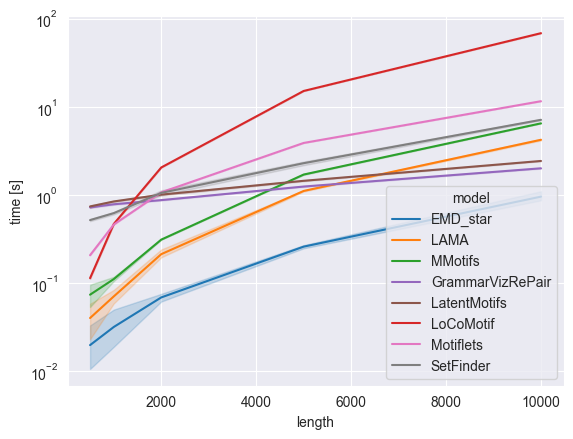

In [4]:
df = load('length')
# df['model'] = pd.Categorical(df['model'], categories=['EMD_star', 'LAMA', 'MMotifs', 'LoCoMotif', 'GrammarVizRePair', 'LatentMotifs', 'Motiflets', 'SetFinder'], ordered=True)
# df = df.sort_values('model')
sns.lineplot(df, x='length', y='time [s]', hue='model', palette=COLOR_PALETTE)
plt.yscale('log')
plt.savefig('tmp')

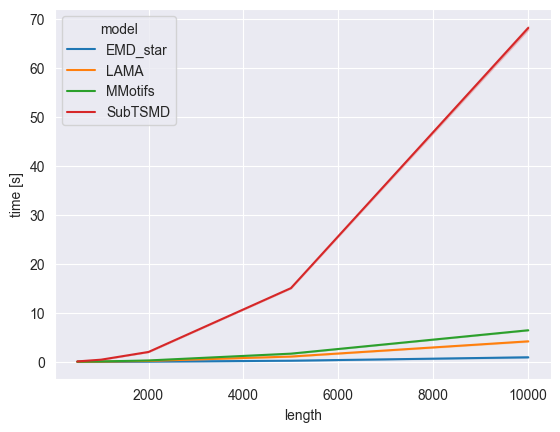

In [5]:
df = load('length', SUBSPACE_METHODS + [SUB_TSMD_METHOD])
df['model'] = df['model'].replace({SUB_TSMD_METHOD: 'SubTSMD'})
sns.lineplot(df, x='length', y='time [s]', hue='model');

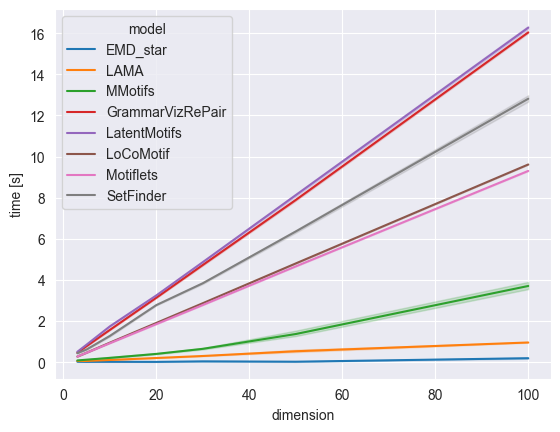

In [6]:
df = load('dimension')
sns.lineplot(df, x='dimension', y='time [s]', hue='model');

### Analysis of components of subspace TSMD

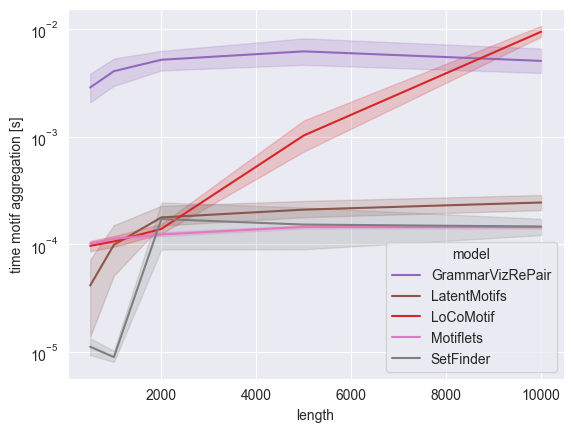

In [7]:
df = load('length', models=UNIVARIATE_METHODS)
sns.lineplot(df, x='length', y='time motif aggregation [s]', hue='model', palette=COLOR_PALETTE)
plt.yscale('log');

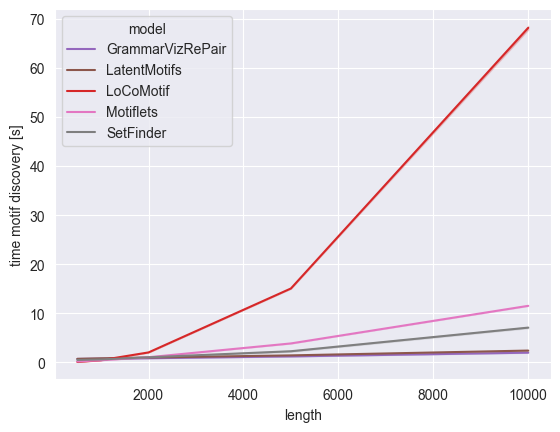

In [8]:
df = load('length', models=UNIVARIATE_METHODS)
sns.lineplot(df, x='length', y='time motif discovery [s]', hue='model', palette=COLOR_PALETTE);

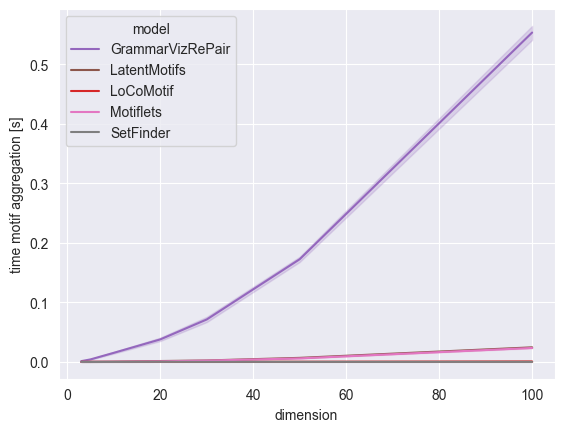

In [9]:
df = load('dimension', models=UNIVARIATE_METHODS)
sns.lineplot(df, x='dimension', y='time motif aggregation [s]', hue='model', palette=COLOR_PALETTE);

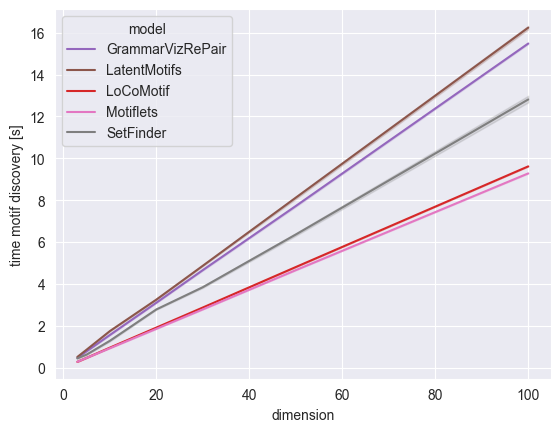

In [10]:
df = load('dimension', models=UNIVARIATE_METHODS)
sns.lineplot(df, x='dimension', y='time motif discovery [s]', hue='model', palette=COLOR_PALETTE);

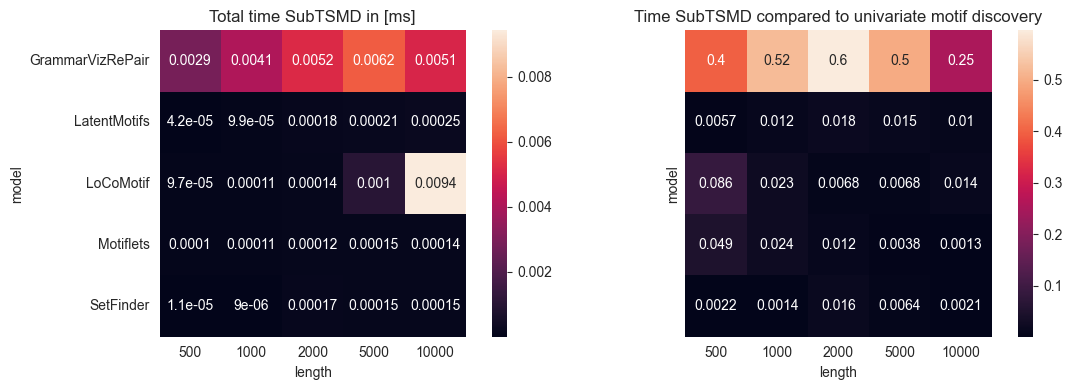

In [12]:
df = load('length', models=UNIVARIATE_METHODS)
df['ratio'] = df['time motif aggregation [s]'] / (df['time motif discovery [s]'] + df['time motif aggregation [s]']) * 100

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4), sharey='all')

sns.heatmap(df.pivot_table(values='time motif aggregation [s]', index='model', columns='length', aggfunc='mean'), annot=True, ax=ax1, square=True)
ax1.set_title('Total time SubTSMD in [ms]')

sns.heatmap(df.pivot_table(values='ratio', index='model', columns='length', aggfunc='mean'), annot=True, ax=ax2, square=True)
ax2.set_title('Time SubTSMD compared to univariate motif discovery')

fig.tight_layout()

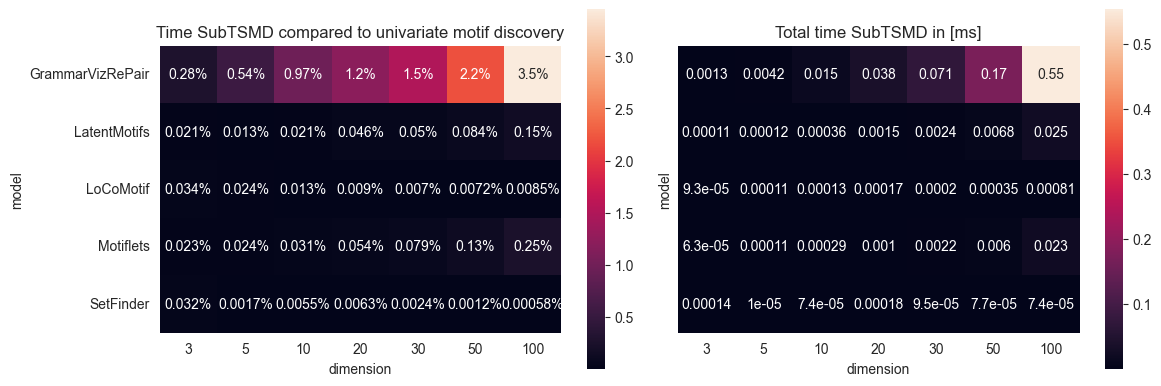

In [13]:
df = load('dimension', models=UNIVARIATE_METHODS)
df['ratio'] = df['time motif aggregation [s]'] / (df['time motif discovery [s]'] + df['time motif aggregation [s]']) * 100

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4), sharey='all')
sns.heatmap(df.pivot_table(values='ratio', index='model', columns='dimension', aggfunc='mean'), annot=True, ax=ax1, square=True)
for t in ax1.texts: t.set_text(t.get_text() + "%")
sns.heatmap(df.pivot_table(values='time motif aggregation [s]', index='model', columns='dimension', aggfunc='mean'), annot=True, ax=ax2, square=True)

ax1.set_title('Time SubTSMD compared to univariate motif discovery')
ax2.set_title('Total time SubTSMD in [ms]')
fig.tight_layout()

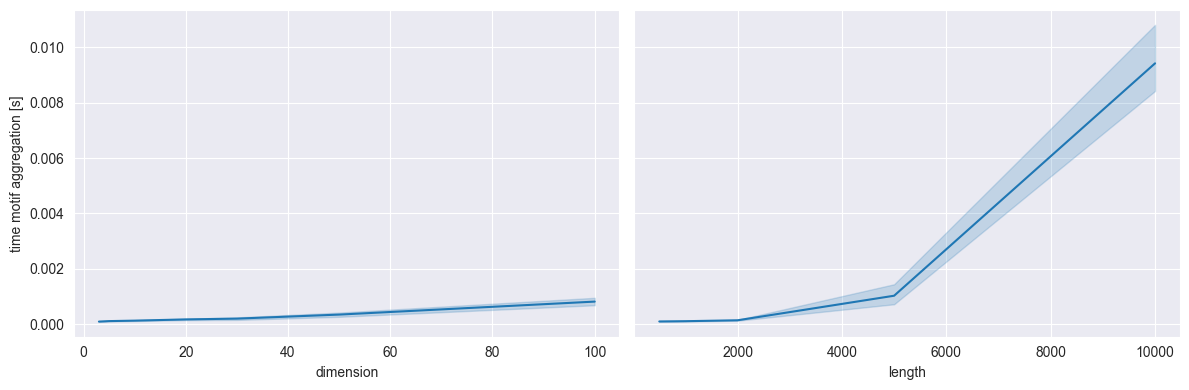

In [14]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4), sharey='all')

df = load('dimension', models=UNIVARIATE_METHODS)
df = df[df['model'] == 'LoCoMotif']
sns.lineplot(df, x='dimension', y='time motif aggregation [s]', ax=ax1)

df = load('length', models=UNIVARIATE_METHODS)
df = df[df['model'] == 'LoCoMotif']
sns.lineplot(df, x='length', y='time motif aggregation [s]', ax=ax2)

fig.tight_layout()

## Scalability SubTSMD

In [16]:
df = pd.read_csv("../results/scalability/SubTSMD.csv")
df.head()

,coverage,dimension,threshold,linkage,nb_motifs,nb_motif_sets,full_numba,repeat,Time [ms]
0,0.5,3,0.5,complete,60,15,True,0,5.700360
1,0.5,3,0.5,complete,60,15,True,1,5.216908
2,0.5,3,0.5,complete,60,15,True,2,5.101561
3,0.5,3,0.5,complete,60,15,True,3,4.704876
4,0.5,3,0.5,complete,60,15,True,4,4.288129


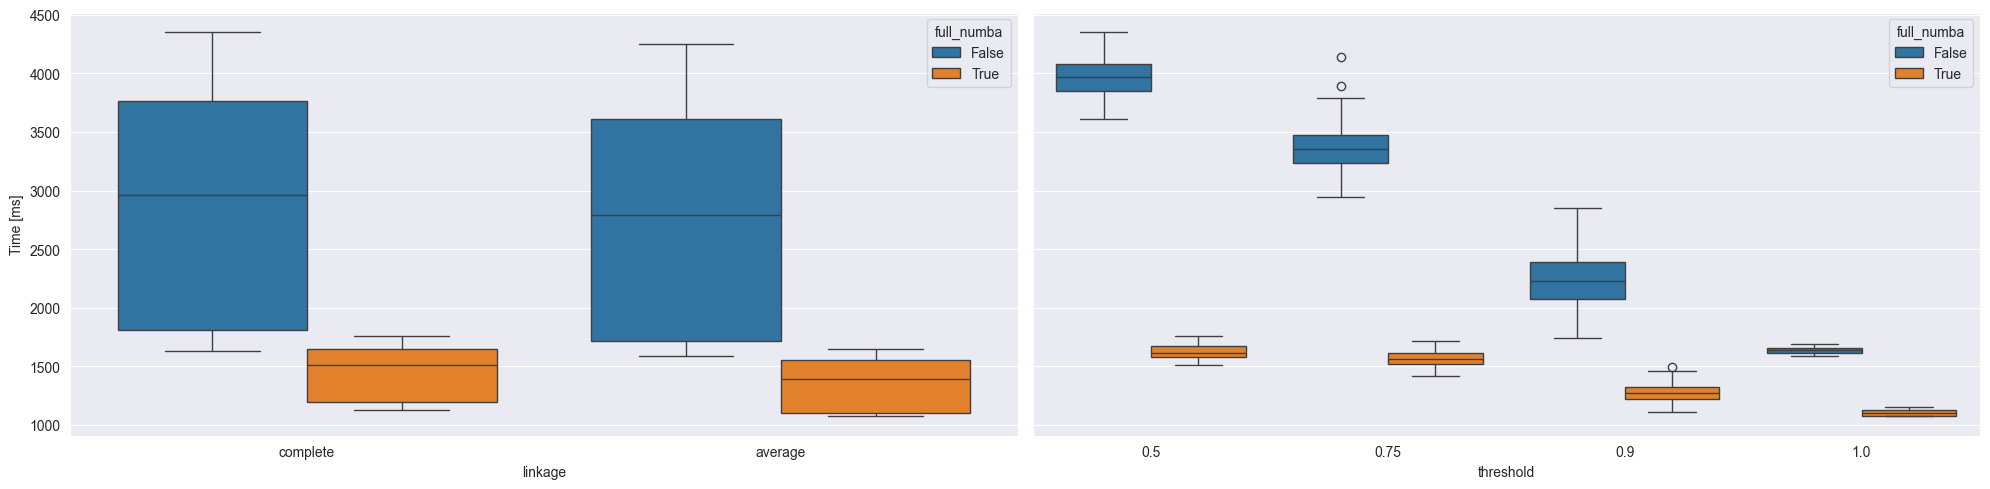

In [17]:
df = pd.read_csv("../results/scalability/SubTSMD.csv")
fig, axs = plt.subplots(1, 2, figsize=(20, 5), sharey='all')
base_case = df[(df['dimension'] == 50) & (df['nb_motifs'] == 60) & (df['nb_motif_sets'] == 15)]
sns.boxplot(base_case, x='linkage', y='Time [ms]', hue='full_numba', ax=axs[0])
sns.boxplot(base_case, x='threshold', y='Time [ms]', hue='full_numba', ax=axs[1])
fig.tight_layout()

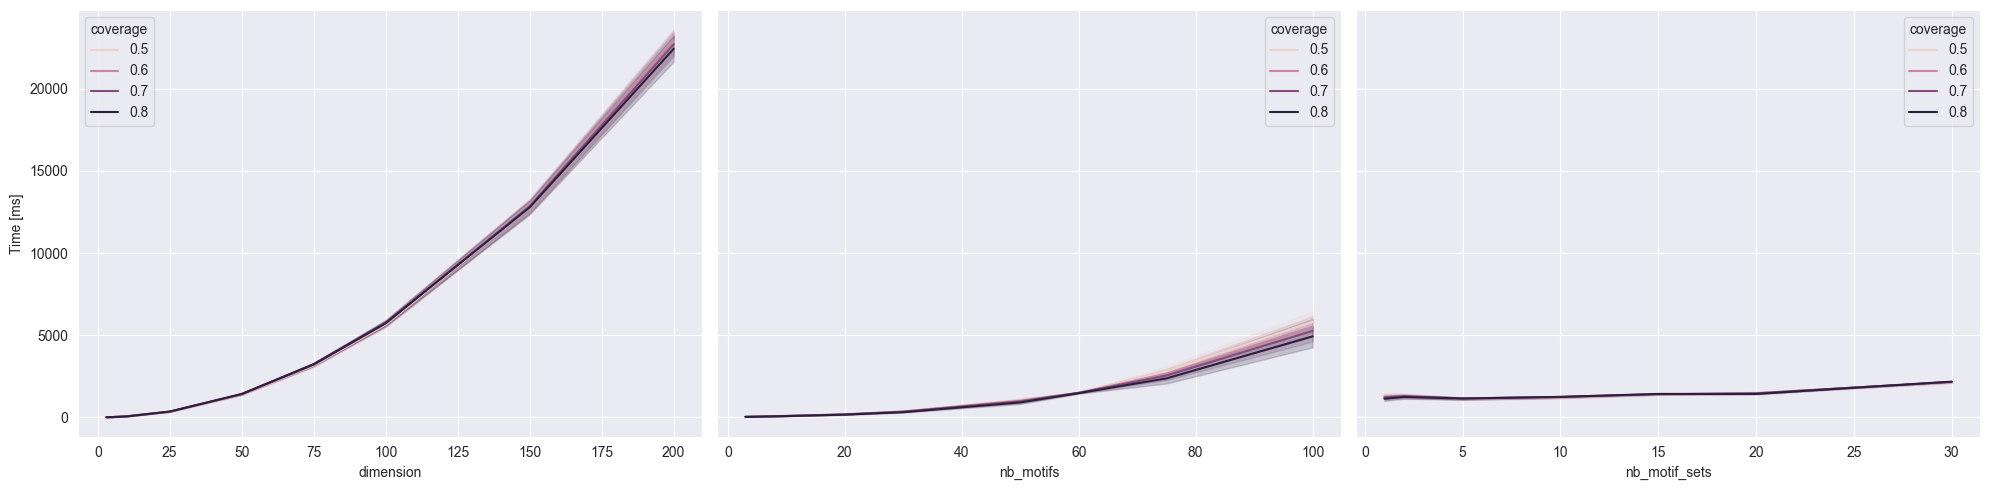

In [18]:
df = pd.read_csv("../results/scalability/SubTSMD.csv")
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(20, 5), sharey='all')
sns.lineplot(df[(df['nb_motifs'] == 60) & (df['nb_motif_sets'] == 15) & df['full_numba']], x='dimension', y='Time [ms]', hue='coverage', ax=ax1)
sns.lineplot(df[(df['dimension'] == 50) & df['full_numba']], x='nb_motifs', y='Time [ms]', hue='coverage', ax=ax2)
sns.lineplot(df[(df['dimension'] == 50) & df['full_numba']], x='nb_motif_sets', y='Time [ms]', hue='coverage', ax=ax3)
fig.tight_layout()

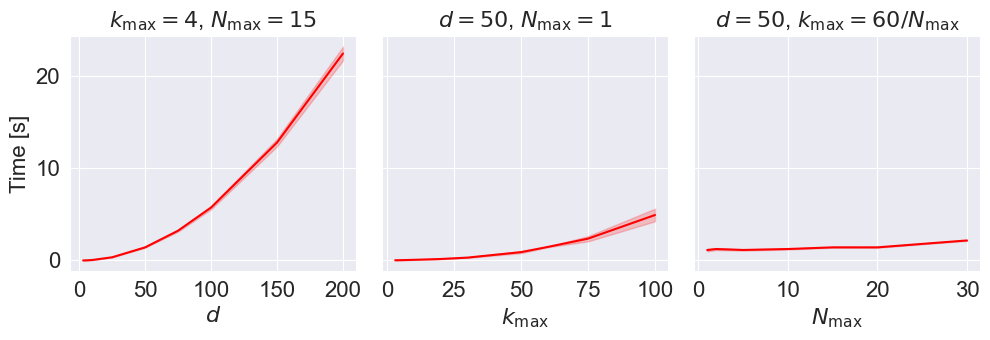

In [20]:
df = pd.read_csv("../results/scalability/SubTSMD.csv")
df = df[(df['coverage'] == 0.8) & df['full_numba']]
df['Time [s]'] = df['Time [ms]'] / 1000

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(10, 3.5), sharey='all')
sns.lineplot(df[(df['nb_motifs'] == 60) & (df['nb_motif_sets'] == 15)], x='dimension', y='Time [s]', ax=ax1, color='red')
ax1.set_xlabel("$d$", fontsize=16)
ax1.set_ylabel('Time [s]', fontsize=16)
ax1.set_xticks([0, 50, 100, 150, 200])
ax1.set_title('$k_\\text{max} = 4$, $N_\\text{max} = 15$', fontsize=16)

sns.lineplot(df[(df['dimension'] == 50)], x='nb_motifs', y='Time [s]', ax=ax2, color='red')
ax2.set_xlabel("$k_\\text{max}$", fontsize=16)
ax2.set_xticks([0, 25, 50, 75, 100])
ax2.set_title('$d=50$, $N_\\text{max} = 1$', fontsize=16)

sns.lineplot(df[(df['dimension'] == 50)], x='nb_motif_sets', y='Time [s]', ax=ax3, color='red')
ax3.set_xlabel("$N_\\text{max}$", fontsize=16)
ax3.set_title('$d=50$, $k_\\text{max} = 60 / N_\\text{max}$', fontsize=16)

ax1.tick_params(axis='both', which='major', labelsize=16)
ax2.tick_params(axis='both', which='major', labelsize=16)
ax3.tick_params(axis='both', which='major', labelsize=16)

fig.tight_layout()
# fig.savefig('figures/scalability-subtsmd.pdf', bbox_inches="tight")

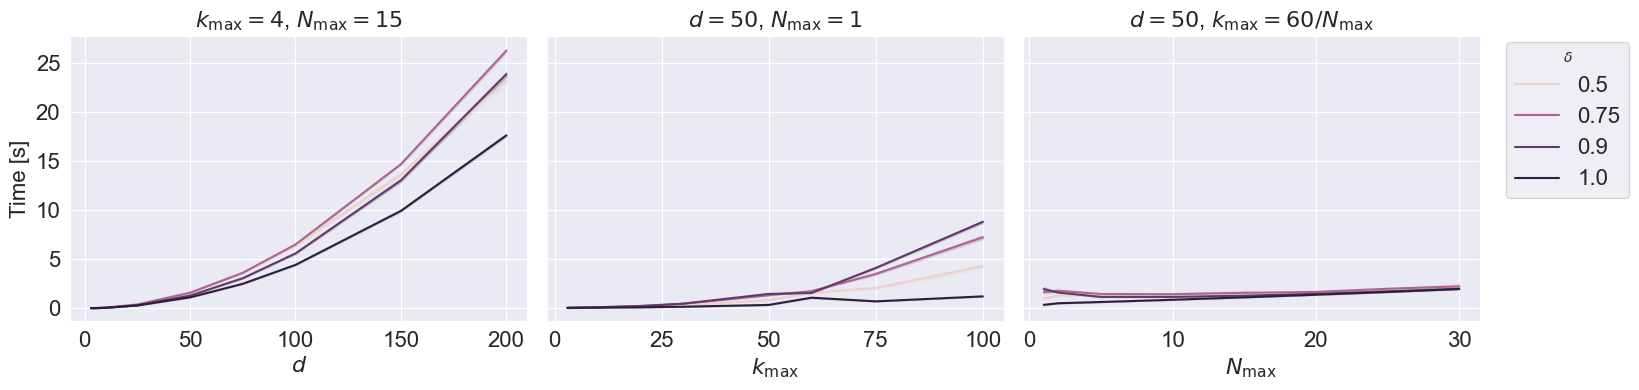

In [21]:
df = pd.read_csv("../results/scalability/SubTSMD.csv")
df = df[df['full_numba']]
df['Time [s]'] = df['Time [ms]'] / 1000

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 4), sharey='all')
sns.lineplot(df[(df['nb_motifs'] == 60) & (df['nb_motif_sets'] == 15)], x='dimension', y='Time [s]', hue='threshold', ax=ax1)
ax1.set_xlabel("$d$", fontsize=16)
ax1.set_ylabel('Time [s]', fontsize=16)
ax1.set_xticks([0, 50, 100, 150, 200])
ax1.set_title('$k_\\text{max} = 4$, $N_\\text{max} = 15$', fontsize=16)

sns.lineplot(df[(df['dimension'] == 50)], x='nb_motifs', y='Time [s]', ax=ax2, hue='threshold')
ax2.set_xlabel("$k_\\text{max}$", fontsize=16)
ax2.set_xticks([0, 25, 50, 75, 100])
ax2.set_title('$d=50$, $N_\\text{max} = 1$', fontsize=16)

sns.lineplot(df[(df['dimension'] == 50)], x='nb_motif_sets', y='Time [s]', ax=ax3, hue='threshold')
ax3.set_xlabel("$N_\\text{max}$", fontsize=16)
ax3.set_title('$d=50$, $k_\\text{max} = 60 / N_\\text{max}$', fontsize=16)

for ax in [ax1, ax2, ax3]:
    ax.tick_params(axis='both', which='major', labelsize=16)
    ax.get_legend().remove()
    
lines_labels = [ax.get_legend_handles_labels() for ax in [fig.axes[0]]]
lines, labels = [sum(lol, []) for lol in zip(*lines_labels)]
fig.legend(lines, labels, title='$\\delta$', loc='upper left', bbox_to_anchor=(1, 0.91), fontsize=16)
fig.tight_layout()

fig.savefig('figures/fig-scalability-subtsmd.png', bbox_inches="tight")

In [22]:
df = pd.read_csv("../results/scalability/SubTSMD-delta.csv")
df = df[df['full_numba']]
df.head()

,coverage,dimension,threshold,linkage,nb_motifs,nb_motif_sets,full_numba,repeat,Time [ms]
0,0.5,50,0.1,average,60,15,True,0,1438.1067
1,0.5,50,0.1,average,60,15,True,1,1326.8647
2,0.5,50,0.1,average,60,15,True,2,1408.4226
3,0.5,50,0.1,average,60,15,True,3,1216.7682
4,0.5,50,0.1,average,60,15,True,4,1249.8547


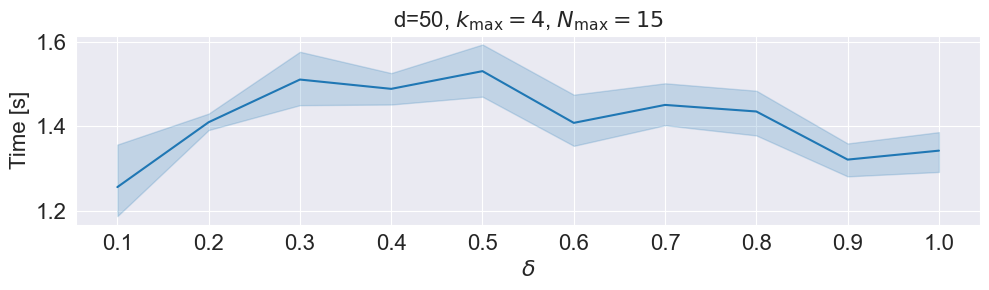

In [23]:
df = pd.read_csv("../results/scalability/SubTSMD-delta.csv")
df = df[(df['coverage'] == 0.6) & df['full_numba']]
df['Time [s]'] = df['Time [ms]'] / 1000

plt.figure(figsize=(10, 3))
sns.lineplot(df, x='threshold', y='Time [s]')
plt.xlabel("$\\delta$", fontsize=16)
plt.ylabel("Time [s]", fontsize=16)
plt.xticks([0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0])
plt.tick_params(axis='both', which='major', labelsize=16)
plt.title('d=50, $k_\\text{max} = 4$, $N_\\text{max} = 15$', fontsize=16)

plt.tight_layout()
plt.savefig('figures/fig-scalability-subtsmd-delta.png', bbox_inches="tight")

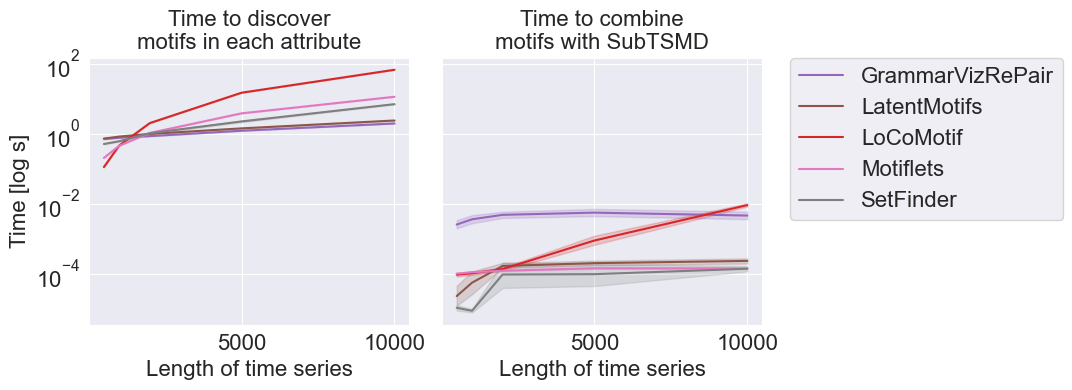

In [43]:
fig, (ax2, ax3) = plt.subplots(1, 2, figsize=(8, 4), sharex='all', sharey='all')

# df = load('length')
# df['model'] = pd.Categorical(df['model'], categories=['EMD_star', 'LAMA', 'MMotifs', 'LoCoMotif', 'GrammarVizRePair', 'LatentMotifs', 'Motiflets', 'SetFinder'], ordered=True)
# df = df.sort_values('model')
# sns.lineplot(df, x='length', y='time [s]', hue='model', ax=ax1)
ax2.set_yscale('log')
# ax1.set_xlabel('Length of time series', fontsize=16)
# ax1.set_ylabel('Time [log s]', fontsize=16)
# ax1.set_title('Total Motif discovery time', fontsize=16)

df = load('length', models=UNIVARIATE_METHODS)

sns.lineplot(df, x='length', y='time motif discovery [s]', hue='model', palette=COLOR_PALETTE, ax=ax2)
ax2.set_title('Time to discover\nmotifs in each attribute', fontsize=16)

sns.lineplot(df, x='length', y='time motif aggregation [s]', hue='model', palette=COLOR_PALETTE, ax=ax3)
ax3.set_title('Time to combine\nmotifs with SubTSMD', fontsize=16)

handles, labels = ax2.get_legend_handles_labels()
fig.legend(handles, labels, loc='upper left', bbox_to_anchor=(0.98, 0.87), fontsize=16)

ax2.set_ylabel('Time [log s]', fontsize=16)
for ax in [ax2, ax3]:
    ax.set_xlabel('Length of time series', fontsize=16)
    ax.tick_params(axis='both', which='major', labelsize=16)
    ax.get_legend().remove()

fig.tight_layout()
fig.savefig('figures/fig-scalability-comparison-univariate.png', bbox_inches="tight")

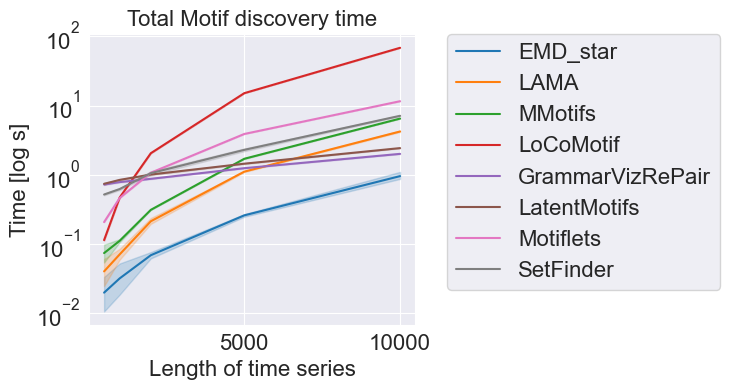

In [40]:
fig, ax1 = plt.subplots(1, 1, figsize=(4.5, 4), sharex='all', sharey='all')

df = load('length')
df['model'] = pd.Categorical(df['model'], categories=['EMD_star', 'LAMA', 'MMotifs', 'LoCoMotif', 'GrammarVizRePair', 'LatentMotifs', 'Motiflets', 'SetFinder'], ordered=True)
df = df.sort_values('model')
sns.lineplot(df, x='length', y='time [s]', hue='model', ax=ax1)
ax1.set_yscale('log')
ax1.set_xlabel('Length of time series', fontsize=16)
ax1.set_ylabel('Time [log s]', fontsize=16)
ax1.set_title('Total Motif discovery time', fontsize=16)

ax1.get_legend().remove()
handles, labels = ax1.get_legend_handles_labels()
fig.legend(handles, labels, loc='upper left', bbox_to_anchor=(0.98, 0.93), fontsize=16)

ax1.set_xlabel('Length of time series', fontsize=16)
ax1.tick_params(axis='both', which='major', labelsize=16)
    
fig.tight_layout()
fig.savefig('figures/fig-scalability-comparison.png', bbox_inches="tight")